# Simulación de permanencia y deserción estudiantil

**Curso:** Dinámica de Sistemas  
**Alumno:** Zamora Montalvo Sebastián Aldair  
**Horizonte:** 60 meses  
**Método:** integración discreta tipo Euler, con paso de 1 mes

> **Importante:** los valores son **datos sintéticos y supuestos referenciales**. No corresponden a cifras oficiales de la UNFV ni de una universidad específica.

Este cuaderno permite mostrar durante la exposición:

1. Los parámetros y ecuaciones del modelo.
2. La ejecución mensual del escenario base.
3. La comparación entre escenarios.
4. Los gráficos principales y la tabla final.


## 1. Importación de librerías

Se utilizan `pandas` para manejar los resultados, `numpy` para cálculos y `matplotlib` para las gráficas.


In [11]:
import base64
from io import StringIO

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.


## 2. Resultados guardados de los cuatro escenarios

Los resultados utilizados en el informe se encuentran incorporados dentro del mismo notebook.  
Por ello, no es necesario subir archivos adicionales a Google Colab.


In [12]:
# Datos de salida de la simulación incorporados en el notebook
DATOS_CSV_BASE64 = {"Base": "...", "Optimista": "...", "Pesimista": "...", "Intervención": "..."}

resultados = {}
for nombre, contenido_b64 in DATOS_CSV_BASE64.items():
    contenido = base64.b64decode(contenido_b64).decode("utf-8")
    resultados[nombre] = pd.read_csv(StringIO(contenido))

for nombre, df in resultados.items():
    print(f"{nombre}: {len(df)} periodos cargados")


Base: 61 periodos cargados
Optimista: 61 periodos cargados
Pesimista: 61 periodos cargados
Intervención: 61 periodos cargados


## 3. Parámetros del escenario base

Los stocks iniciales son:

- 7 800 estudiantes comprometidos.
- 1 200 estudiantes en riesgo.
- 0 desertores acumulados.
- 0 graduados acumulados.
- Capacidad inicial de apoyo de 600 estudiantes por mes.

Los principales parámetros son supuestos de modelamiento y pueden modificarse para experimentar.


In [13]:
PARAMETROS_BASE = {
    "horizonte": 60,
    "paso": 1,
    "comprometidos_iniciales": 7800.0,
    "riesgo_inicial": 1200.0,
    "capacidad_apoyo_inicial": 600.0,
    "capacidad_docente": 9500.0,
    "tasa_base_riesgo": 0.012,
    "tasa_base_recuperacion": 0.055,
    "tasa_base_desercion": 0.018,
    "tasa_base_graduacion": 0.010,
    "estres_economico": 0.55,
    "calidad_tutoria": 0.70,
    "capacidad_objetivo": 650.0,
    "tiempo_ajuste_capacidad": 8.0,
    "depreciacion_capacidad": 0.01,
    "eficacia_alerta": 0.0,
}

pd.DataFrame(
    PARAMETROS_BASE.items(),
    columns=["Parámetro", "Valor"]
)


,Parámetro,Valor
0,horizonte,60.00
1,paso,1.00
2,comprometidos_iniciales,"7,800.00"
3,riesgo_inicial,"1,200.00"
4,capacidad_apoyo_inicial,600.00
5,capacidad_docente,"9,500.00"
6,tasa_base_riesgo,0.01
7,tasa_base_recuperacion,0.06
8,tasa_base_desercion,0.02
9,tasa_base_graduacion,0.01


## 4. Ecuaciones principales

El stock central se actualiza así:

\[
Riesgo_{t+1}=Riesgo_t+EntradaRiesgo_t-Recuperación_t-Deserción_t
\]

La simulación también calcula presión académica, cobertura, motivación, satisfacción y capacidad institucional.


In [14]:
def limitar(valor, minimo, maximo):
    """Limita una variable a un intervalo permitido."""
    return max(minimo, min(maximo, valor))


def simular_escenario_base(parametros, admisiones_externas):
    """Ejecuta el modelo stock-flow durante 60 meses mediante Euler discreto."""
    comprometidos = parametros["comprometidos_iniciales"]
    en_riesgo = parametros["riesgo_inicial"]
    desertores_acumulados = 0.0
    graduados_acumulados = 0.0
    capacidad_apoyo = parametros["capacidad_apoyo_inicial"]

    registros = []

    for mes in range(parametros["horizonte"] + 1):
        matricula = comprometidos + en_riesgo

        presion = limitar(
            ((matricula / parametros["capacidad_docente"]) - 0.85) / 0.35,
            0.0,
            1.5,
        )

        cobertura = min(1.0, capacidad_apoyo / max(en_riesgo, 1.0))

        motivacion = limitar(
            0.82
            - 0.26 * presion
            - 0.24 * parametros["estres_economico"]
            + 0.28 * cobertura * parametros["calidad_tutoria"],
            0.15,
            0.98,
        )

        tasa_riesgo = (
            parametros["tasa_base_riesgo"]
            * (
                1
                + 0.85 * presion
                + 0.80 * parametros["estres_economico"]
                + 0.75 * (1 - motivacion)
            )
            * (1 - parametros["eficacia_alerta"])
        )

        tasa_recuperacion = (
            parametros["tasa_base_recuperacion"]
            * (
                0.45
                + 1.25 * cobertura * parametros["calidad_tutoria"]
                + 0.55 * motivacion
            )
        )

        tasa_desercion = (
            parametros["tasa_base_desercion"]
            * (
                1
                + 0.75 * parametros["estres_economico"]
                + 0.65 * (1 - motivacion)
            )
            * (
                1
                - 0.58 * cobertura * parametros["calidad_tutoria"]
            )
        )

        satisfaccion = limitar(
            0.047857142857
            + 0.892857142857 * motivacion
            - 0.067857142857 * presion
            + 0.034285714286 * parametros["estres_economico"],
            0.0,
            1.0,
        )

        admisiones = float(admisiones_externas[mes])
        entrada_riesgo = comprometidos * tasa_riesgo
        recuperacion = en_riesgo * tasa_recuperacion
        desercion = en_riesgo * tasa_desercion
        graduacion = (
            comprometidos
            * parametros["tasa_base_graduacion"]
            * (0.75 + 0.35 * motivacion)
        )

        registros.append({
            "month": mes,
            "engaged": comprometidos,
            "at_risk": en_riesgo,
            "enrolled": matricula,
            "cumulative_dropouts": desertores_acumulados,
            "cumulative_graduates": graduados_acumulados,
            "support_capacity": capacidad_apoyo,
            "admissions": admisiones,
            "to_risk": entrada_riesgo,
            "recovery": recuperacion,
            "dropouts": desercion,
            "graduates": graduacion,
            "pressure": presion,
            "coverage": cobertura,
            "motivation": motivacion,
            "satisfaction": satisfaccion,
            "risk_rate": tasa_riesgo,
            "dropout_rate": tasa_desercion,
        })

        # Integración discreta de Euler
        comprometidos = max(
            0.0,
            comprometidos
            + admisiones
            + recuperacion
            - entrada_riesgo
            - graduacion,
        )

        en_riesgo = max(
            0.0,
            en_riesgo
            + entrada_riesgo
            - recuperacion
            - desercion,
        )

        desertores_acumulados += desercion
        graduados_acumulados += graduacion

        aumento_capacidad = (
            parametros["capacidad_objetivo"] - capacidad_apoyo
        ) / parametros["tiempo_ajuste_capacidad"]

        depreciacion = (
            parametros["depreciacion_capacidad"] * capacidad_apoyo
        )

        capacidad_apoyo = max(
            0.0,
            capacidad_apoyo + aumento_capacidad - depreciacion,
        )

    return pd.DataFrame(registros)


## 5. Ejecución del escenario base

La serie de admisiones se considera una entrada externa sintética con patrón semestral.  
El resto de los stocks, flujos y auxiliares se calcula dentro del modelo.


In [15]:
admisiones_base = resultados["Base"]["admissions"].to_numpy()

simulacion_base = simular_escenario_base(
    PARAMETROS_BASE,
    admisiones_base,
)

simulacion_base.head()


,month,engaged,at_risk,enrolled,cumulative_dropouts,cumulative_graduates,support_capacity,admissions,to_risk,recovery,dropouts,graduates,pressure,coverage,motivation,satisfaction,risk_rate,dropout_rate
0,0,"7,800.00","1,200.00","9,000.00",0.00,0.00,600.00,260.99,177.02,84.48,27.52,77.98,0.28,0.50,0.71,0.69,0.02,0.02
1,1,"7,890.47","1,265.02","9,155.48",27.52,77.98,600.25,144.14,184.05,86.85,29.59,78.41,0.32,0.47,0.70,0.67,0.02,0.02
2,2,"7,858.99","1,332.63","9,191.61",57.11,156.40,600.47,143.88,184.72,89.65,31.65,77.89,0.34,0.45,0.69,0.66,0.02,0.02
3,3,"7,829.91","1,396.05","9,225.95",88.76,234.29,600.65,86.20,185.33,92.27,33.58,77.42,0.35,0.43,0.68,0.65,0.02,0.02
4,4,"7,745.62","1,455.53","9,201.15",122.34,311.71,600.82,86.26,182.85,94.92,35.33,76.55,0.34,0.41,0.68,0.65,0.02,0.02


## 6. Verificación de reproducibilidad

Esta prueba compara la ejecución del modelo con el resultado guardado utilizado en el informe.


In [16]:
columnas_verificacion = [
    "engaged",
    "at_risk",
    "cumulative_dropouts",
    "cumulative_graduates",
    "support_capacity",
    "pressure",
    "coverage",
    "motivation",
    "satisfaction",
]

coincide = np.allclose(
    simulacion_base[columnas_verificacion].to_numpy(),
    resultados["Base"][columnas_verificacion].to_numpy(),
    rtol=1e-9,
    atol=1e-9,
)

print("¿La simulación base reproduce los resultados del informe?", coincide)


¿La simulación base reproduce los resultados del informe? True


## 7. Resultados finales de los cuatro escenarios

Esta es la tabla principal que conviene mostrar durante la exposición.


In [17]:
resumen = []

for nombre, df in resultados.items():
    final = df.iloc[-1]
    resumen.append({
        "Escenario": nombre,
        "Matrícula mes 60": round(final["enrolled"]),
        "En riesgo mes 60": round(final["at_risk"]),
        "Desertores acumulados": round(final["cumulative_dropouts"] + final["dropouts"]),
        "Graduados acumulados": round(final["cumulative_graduates"]),
        "Satisfacción final (%)": round(final["satisfaction"] * 100, 1),
    })

tabla_resumen = pd.DataFrame(resumen)
tabla_resumen


,Escenario,Matrícula mes 60,En riesgo mes 60,Desertores acumulados,Graduados acumulados,Satisfacción final (%)
0,Base,9624,2278,3180,4379,58.70
1,Optimista,10457,2073,1959,4952,61.10
2,Pesimista,8484,2365,5459,3680,56.10
3,Intervención,10783,1147,1483,5211,72.60


## 8. Gráfico principal: desertores acumulados

Este gráfico permite demostrar el efecto de la política SIPAT frente al escenario base.


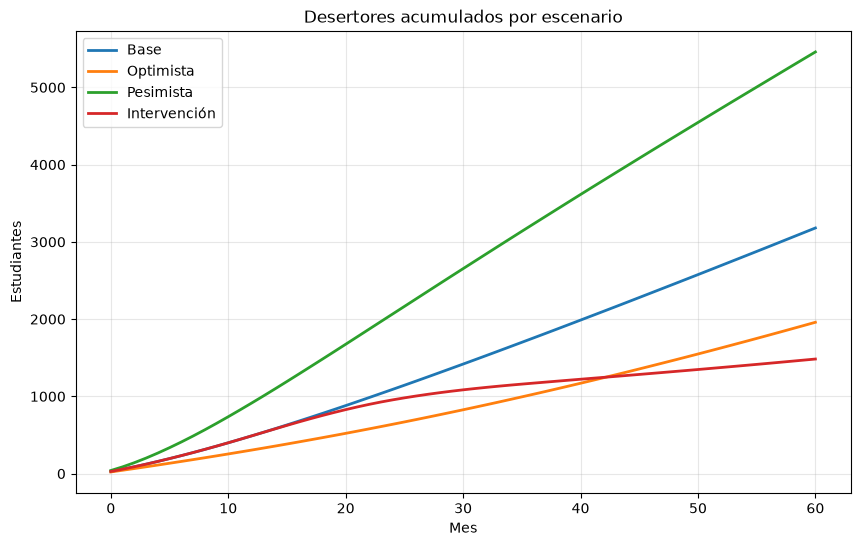

In [18]:
plt.figure(figsize=(10, 6))

for nombre, df in resultados.items():
    desertores_totales = df["cumulative_dropouts"] + df["dropouts"]
    plt.plot(df["month"], desertores_totales, label=nombre, linewidth=2)

plt.title("Desertores acumulados por escenario")
plt.xlabel("Mes")
plt.ylabel("Estudiantes")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## 9. Gráfico principal: estudiantes en riesgo

La intervención comienza desde el mes 12 y reduce progresivamente la acumulación de riesgo.


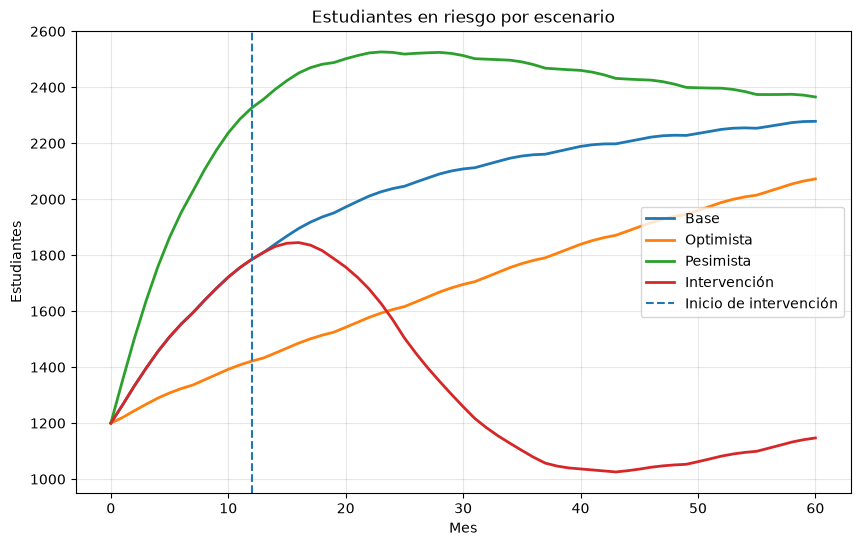

In [19]:
plt.figure(figsize=(10, 6))

for nombre, df in resultados.items():
    plt.plot(df["month"], df["at_risk"], label=nombre, linewidth=2)

plt.axvline(12, linestyle="--", linewidth=1.5, label="Inicio de intervención")
plt.title("Estudiantes en riesgo por escenario")
plt.xlabel("Mes")
plt.ylabel("Estudiantes")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## 10. Indicador central de la intervención

La diferencia entre el escenario base y el escenario SIPAT se interpreta como impacto potencial dentro del caso referencial.


In [20]:
base_final = resultados["Base"].iloc[-1]
interv_final = resultados["Intervención"].iloc[-1]

desertores_base = (
    base_final["cumulative_dropouts"] + base_final["dropouts"]
)
desertores_intervencion = (
    interv_final["cumulative_dropouts"] + interv_final["dropouts"]
)

evitados = desertores_base - desertores_intervencion
reduccion = evitados / desertores_base * 100

print(f"Desertores del escenario base: {desertores_base:,.0f}")
print(f"Desertores con SIPAT: {desertores_intervencion:,.0f}")
print(f"Interrupciones evitadas: {evitados:,.0f}")
print(f"Reducción estimada: {reduccion:.1f}%")


Desertores del escenario base: 3,180
Desertores con SIPAT: 1,483
Interrupciones evitadas: 1,697
Reducción estimada: 53.4%


## Guion breve para mostrar el notebook

Durante la exposición, no es necesario explicar cada línea. Puedes decir:

> “El modelo fue implementado en Python con un horizonte de 60 meses y un paso mensual. Los stocks principales son estudiantes comprometidos, estudiantes en riesgo, desertores, graduados y capacidad de apoyo. En cada periodo se calculan presión, cobertura, motivación y las tasas de transición. Después se actualizan los stocks mediante el método de Euler. Los datos son sintéticos y sirven para comparar políticas, no para predecir cifras oficiales.”

Después muestra:

1. La tabla de parámetros.
2. La función `simular_escenario_base`.
3. La verificación que devuelve `True`.
4. La tabla final de escenarios.
5. Los dos gráficos principales.
